# Metricas

Practicar métricas fundamentales para:

- Regresión: MAE, RMSE, R² (+ robusta: MedAE).
- Clasificación: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC.

La idea del ejercicio es cojer 1 o 2 datasets reales, para aplicar regresion y clasificacion y aplicar todas estas metricas

# 1. Regresion

## Dataset: Communities and Crime

El dataset tiene 128 variables, que se agrupan principalmente en:

- Socioeconómicas: Ingreso medio por familia, porcentaje de personas bajo la línea de pobreza, tasa de desempleo.

- Demográficas: Edad de la población, raza, densidad poblacional.

- Familiares: Porcentaje de hogares con ambos padres presentes, porcentaje de divorcios.

- Vivienda: Porcentaje de personas que alquilan vs. dueños, hacinamiento, valor de la propiedad.

- Policiales: (Muchas tienen valores nulos) Número de oficiales, presupuesto policial.

La columna que vas a predecir es ViolentCrimesPerPop.
Representa la suma de incidentes (asesinatos, violaciones, robos y asaltos agravados) por cada 100,000 habitantes. Lo interesante es que ya viene normalizada (escalada de 0 a 1).

- Valor 0.00: Comunidad con crimen muy bajo.

- Valor 1.00: Comunidad con crimen extremadamente alto.

In [10]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
communities_and_crime = fetch_ucirepo(id=183) 
  
# data (as pandas dataframes) 
X = communities_and_crime.data.features 
y = communities_and_crime.data.targets 

In [11]:
X

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,?,0.02,0.12,0.45,?,?,?,?,0.00,?
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,?,0.01,0.21,0.02,?,?,?,?,0.00,?
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,?,0.02,0.39,0.28,?,?,?,?,0.00,?
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,?,0.04,0.09,0.02,?,?,?,?,0.00,?
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,?,?,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,?,0.01,0.28,0.05,?,?,?,?,0.00,?
1990,6,?,?,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,?,0.02,0.37,0.20,?,?,?,?,0.00,?
1991,9,9,80070,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.25,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28
1992,25,17,72600,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.19,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18


In [12]:
y

,ViolentCrimesPerPop
0,0.20
1,0.67
2,0.43
3,0.12
4,0.03
...,...
1989,0.09
1990,0.45
1991,0.23
1992,0.19


In [13]:
features_a_usar = [
    'PctIlleg', 'pctWInvInc', 'PctPopUnderPov', 
    'PctKids2Par', 'racePctWhite'
]

Usaremos 5 features

1. PctIlleg (Porcentaje de nacimientos de padres no casados)
Estadísticamente, es una de las variables con mayor correlación positiva con el crimen en este dataset. Refleja estructuras familiares que, en el contexto de los datos de 1990, se asociaban a entornos con menos red de apoyo.

2. pctWInvInc (Porcentaje de hogares con ingresos por inversiones/rentas)
Esta es una variable "espejo" de la riqueza. A mayor porcentaje de gente con inversiones, menor suele ser la tasa de criminalidad. Es excelente para ver una correlación negativa clara.

3. PctPopUnderPov (Porcentaje de personas bajo el nivel de pobreza)
Fundamental para cualquier modelo sociológico. Aquí podrás practicar cómo el MAE y el RMSE cambian cuando incluyes variables de desigualdad económica.

4. PctKids2Par (Porcentaje de niños en hogares con dos padres)
Es un predictor muy fuerte de estabilidad social en este dataset específico. Suele tener una relación inversa muy marcada con ViolentCrimesPerPop.

5. racePctWhite o racePctHisp (Composición demográfica)
Aunque es un tema sensible, en el análisis de datos de EE. UU. de los años 90, la segregación racial estaba fuertemente ligada a la falta de recursos económicos. Usarla te permite discutir en clase sobre sesgos en los datos y ética en IA.

In [14]:
X = X[features_a_usar]
y = y['ViolentCrimesPerPop']

import pandas as pd

df = pd.concat([X,y],axis=1)
df

,PctIlleg,pctWInvInc,PctPopUnderPov,PctKids2Par,racePctWhite,ViolentCrimesPerPop
0,0.14,0.60,0.19,0.59,0.90,0.20
1,0.24,0.45,0.24,0.47,0.74,0.67
2,0.46,0.39,0.27,0.44,0.56,0.43
3,0.33,0.43,0.10,0.54,0.08,0.12
4,0.06,0.68,0.06,0.91,0.95,0.03
...,...,...,...,...,...,...
1989,0.11,0.64,0.16,0.68,0.87,0.09
1990,0.42,0.30,0.32,0.63,0.28,0.45
1991,0.54,0.45,0.31,0.42,0.69,0.23
1992,0.17,0.55,0.16,0.65,0.87,0.19


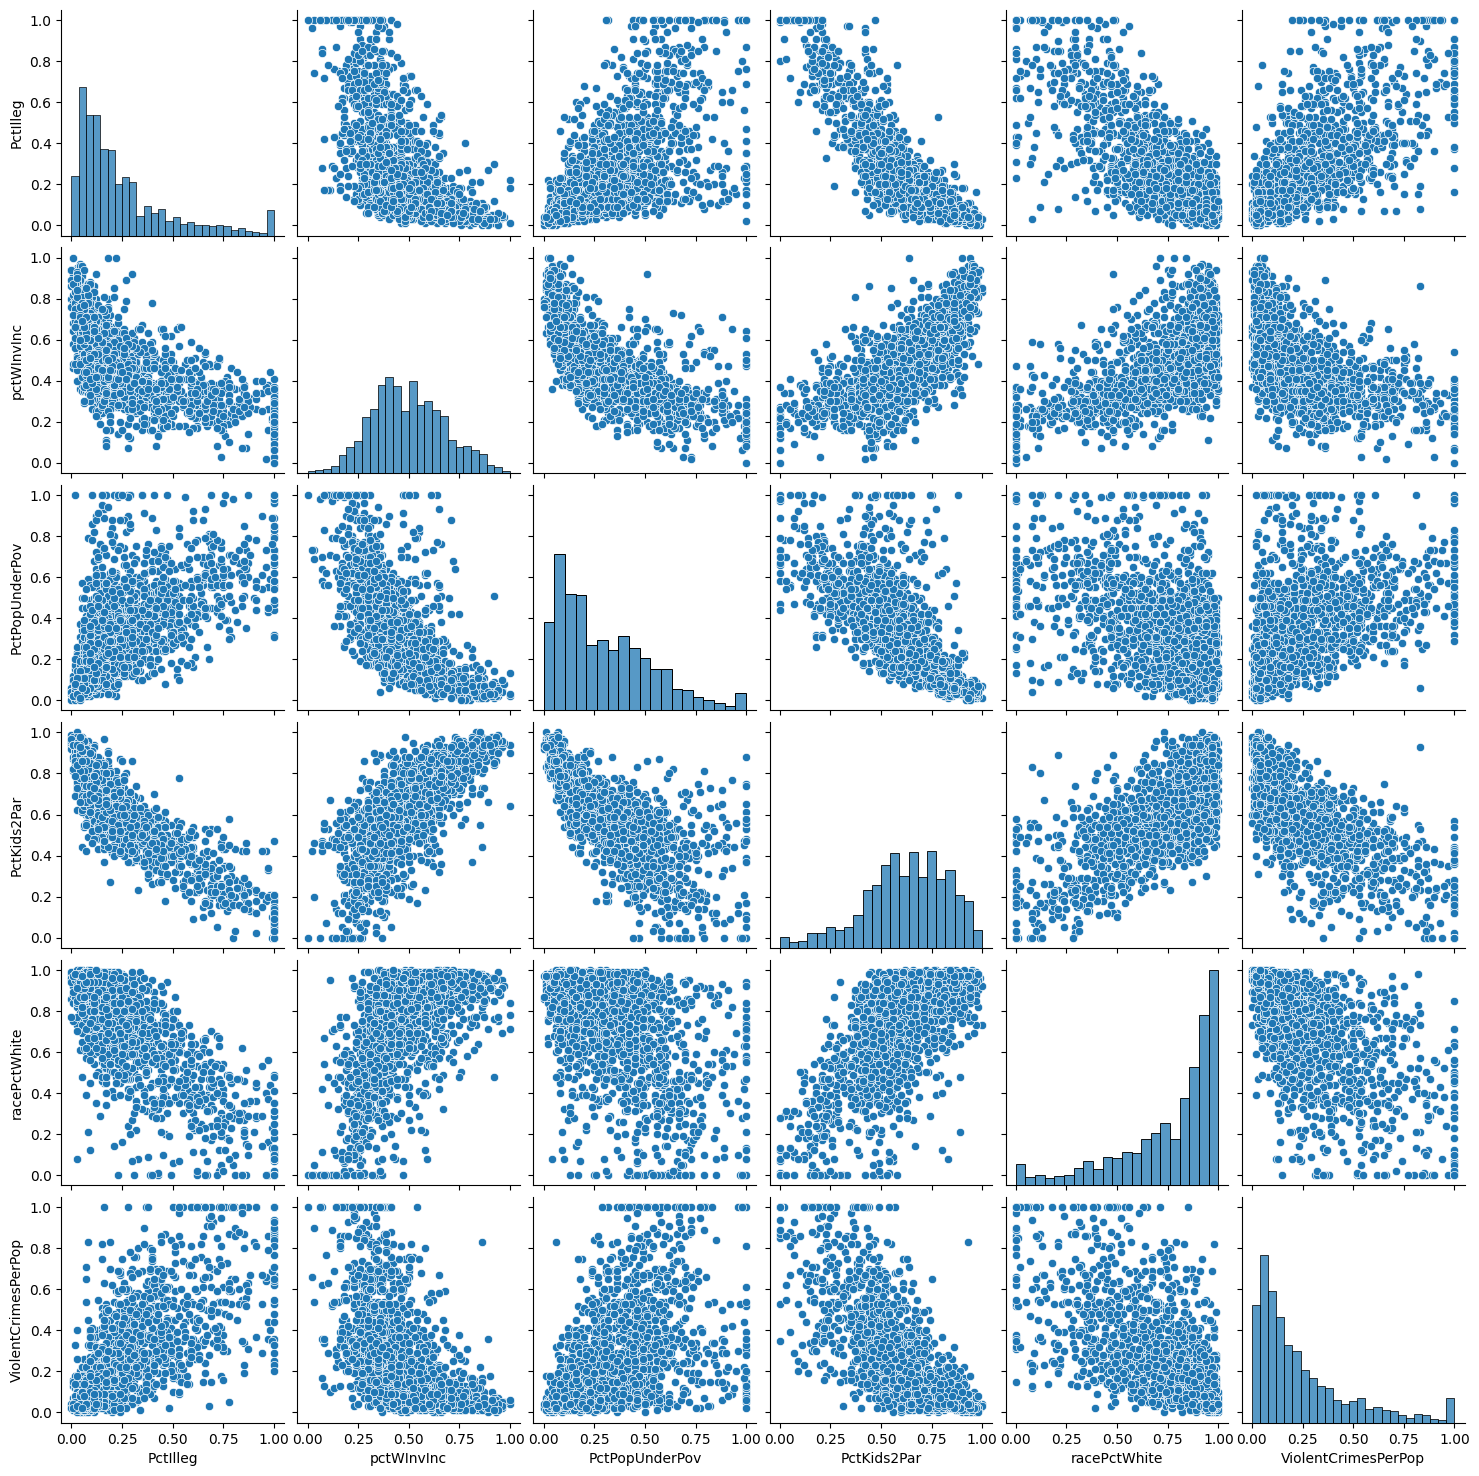

In [16]:
import seaborn as sns
sns.pairplot(df)

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, \
                            median_absolute_error
from sklearn.tree import DecisionTreeRegressor

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.3,random_state=42)

X_test, X_val, y_test, y_val = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

In [19]:
lin_reg = LinearRegression()

lin_reg.fit(X_train,y_train)

y_pred_val = lin_reg.predict(X_val)

In [23]:
tree = DecisionTreeRegressor()

tree.fit(X_train, y_train)

y_pred_val_tree = tree.predict(X_val)

In [24]:
import numpy as np
# Veamos Metricas

mae_reg = mean_absolute_error(y_val,y_pred_val)
r2_reg = r2_score(y_val,y_pred_val)
rmse_reg = np.sqrt(mean_squared_error(y_val,y_pred_val))
medae_reg = median_absolute_error(y_val,y_pred_val)

mae_tree = mean_absolute_error(y_val,y_pred_val_tree)
r2_tree = r2_score(y_val,y_pred_val_tree)
rmse_tree = np.sqrt(mean_squared_error(y_val,y_pred_val_tree))
medae_tree = median_absolute_error(y_val,y_pred_val_tree)

metricas = pd.DataFrame({
    "MAE": [mae_reg, mae_tree],
    "R2": [r2_reg,r2_tree],
    "RMSE": [rmse_reg,rmse_tree],
    "MedAE": [medae_reg,medae_tree]
}, index=["Regresión Lineal","DecisionTreeRegressor"])

metricas

,MAE,R2,RMSE,MedAE
Regresión Lineal,0.099537,0.583086,0.140862,0.065031
DecisionTreeRegressor,0.133733,0.167323,0.199071,0.080000


# 2. Clasificacion

Para practicar Accuracy, Precision, Recall, F1 y ROC-AUC, necesitamos convertir nuestra variable continua en categorías. Vamos a clasificar las comunidades en:

- 0 (Baja/Media Criminalidad)

- 1 (Alta Criminalidad)

In [25]:
# Crear variable binaria basada en la mediana de y
mediana_crimen = y.median()

y_bin = (y > mediana_crimen).astype(int)

# Rehacer el split pero ahora con la variable binaria
# Usamos el mismo random_state para que las filas coincidan con tu ejercicio anterior
X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(X, y_bin, test_size=0.3, random_state=42)
X_test_c, X_val_c, y_test_c, y_val_c = train_test_split(X_temp_c, y_temp_c, test_size=0.5, random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [28]:
log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)
y_pred_logistic = log_reg.predict(X_val_c)
y_probs = log_reg.predict_proba(X_val_c)[:,1]

In [30]:
print(classification_report(y_val_c,y_pred_logistic))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       157
           1       0.82      0.76      0.79       143

    accuracy                           0.81       300
   macro avg       0.81      0.80      0.81       300
weighted avg       0.81      0.81      0.81       300



- Accuracy (0.81): Tu modelo acierta en el 81% de los casos totales. Es una base sólida

- Precision (0.82 para Clase 1): De todas las comunidades que tu modelo marcó como "Peligrosas", el 82% realmente lo eran. Tienes pocos "falsos positivos".

- Recall / Sensibilidad (0.76 para Clase 1): Aquí está el punto de mejora. El modelo detectó el 76% de las comunidades peligrosas reales. Un 24% de zonas con alto crimen se le "escaparon" (falsos negativos).

Nota ética: En seguridad, solemos preferir un Recall más alto para no ignorar zonas de riesgo.

- F1-Score (0.79 para Clase 1): Es el equilibrio entre Precision y Recall. Un 0.79 indica un modelo muy robusto y confiable.

In [32]:
auc_score = roc_auc_score(y_val_c,y_probs)
print(f"ROC-AUC Scores: {auc_score:.4f}")

ROC-AUC Scores: 0.8674


Hay una probabilidad del 86.7% de que, si tomas una comunidad peligrosa y una segura al azar, el modelo clasifique correctamente a la peligrosa con un puntaje mayor.